# Описание датасета 

price - цена в долларах США (326-18 823 долл.)

carat - вес бриллианта в каратах (0,2-5,01)

cut - качество огранки (Справедливая, Хорошая, очень хорошая, Премиум, Идеальная)

color - цвет бриллианта, от J (наихудший) до D (наилучший)

clarity - показатель чистоты бриллианта (I1 (наихудший), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (наилучший)).

x - длина в мм (0--10,74)

y -  ширина в мм (0--58,9)

z - глубина в мм (0--31,8)

depth - общая глубина в процентах = z / среднее значение(x, y) = 2 * z / (x + y) (43--79)

table - Ширина огранки бриллианта, выраженная в процентах от его среднего диаметра

# Импорт основных библиотек

In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from helper import *
from plots import *
import random

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

## 1. Изучение структуры данных

In [4]:
df = pd.read_csv('diamonds.csv')
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
# Смотрим на детали
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
# Смотрим на статистики по числовым переменным (категориальные сюда не входят)
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 2. Проверка на корректность и качество данных

### 2.1 Проверка на дубликаты

In [7]:
# Подсчет числа дублированных строк
df.duplicated().sum() 

np.int64(0)

Дубликатов в датасете нет

### 2.2 Пропущенные значения

In [8]:
# выводим число пропущенных значений по каждому столбцу
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Пропусков в датасете нет

## 2.3 Корректность по столбцам

Из df.describe() видно что x, y, z имеют нулевые значения, чего быть не может, рассмотрим эти признаки поподробнее 

In [9]:
# сколько 0 в x 
len(df[df['x'] == 0]) 

8

In [10]:
# сколько 0 в y 
len(df[df['y'] == 0]) 

7

In [11]:
# сколько 0 в z 
len(df[df['z'] == 0]) 

20

Так как нулевых значений мало, их можно будет позже удалить 

## 3. Детальное изучение признаков (и таргета)

### 3.1 Числовые переменные

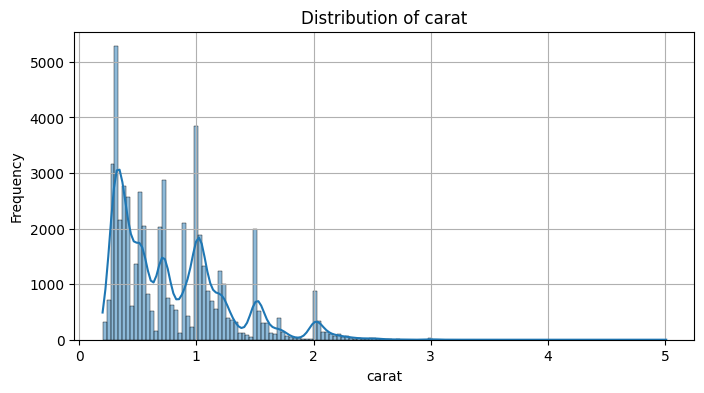

In [12]:
# Строим гистограмму распределения carat
plot_hist_numeric(df, 'carat')

Значения распределены нестабильно в диапазоне от 0.2 до 2, с сильными выбросами в 0.4, 1, 1.5

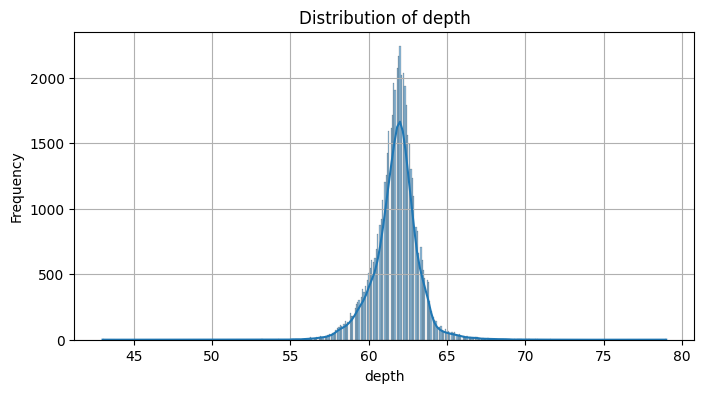

In [13]:
# Строим гистограмму распределения depth
plot_hist_numeric(df, 'depth')

Нормальное распределение 

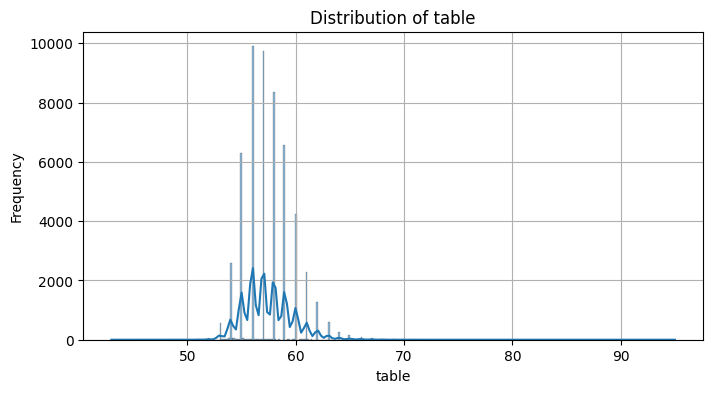

In [14]:
# Строим гистограмму распределения table
plot_hist_numeric(df, 'table')

Основная масса значений в диапазоне от 53 до 62. 

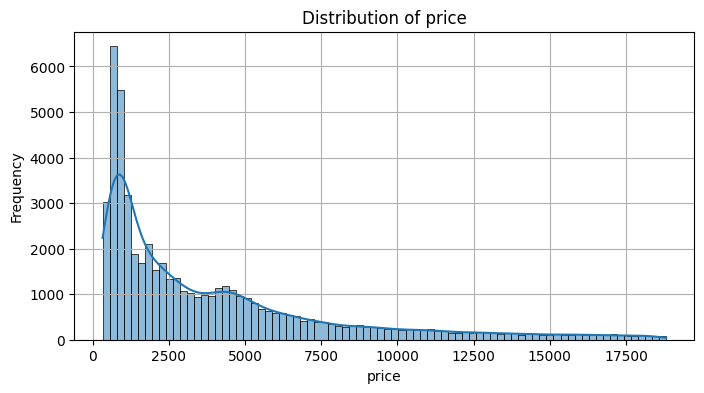

In [15]:
# Строим гистограмму распределения price
plot_hist_numeric(df, 'price')

Данные распределены экспоненциально, что в целом характерно для цен 

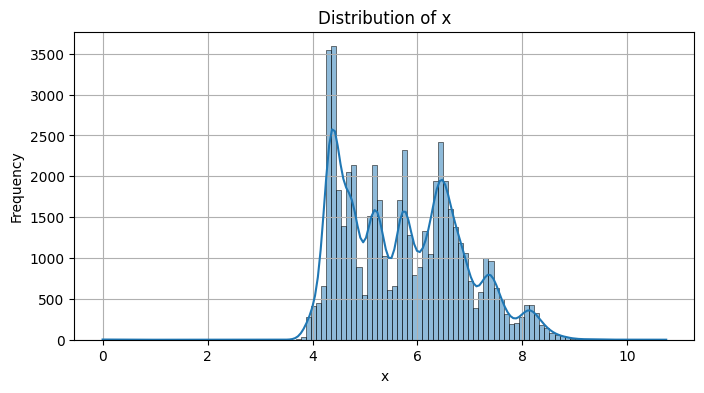

In [16]:
# Строим гистограмму распределения x
plot_hist_numeric(df, 'x')

Основная масса значений распределена между 4 и 9 с выбросом в 4.5

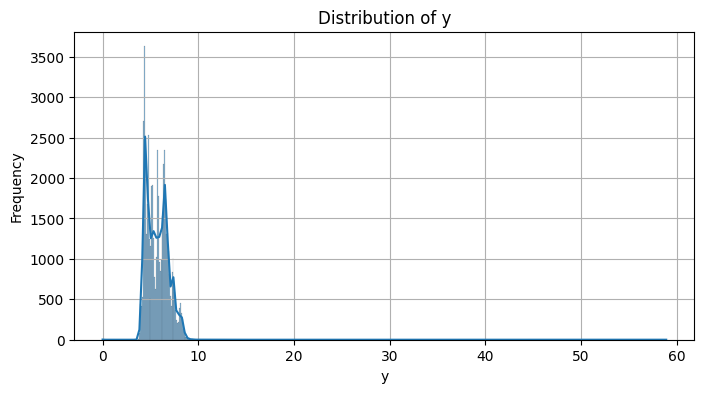

In [17]:
# Строим гистограмму распределения y
plot_hist_numeric(df, 'y')

Основная масса значений распределена от 4 до 9 с сильным выбросом в 4. 

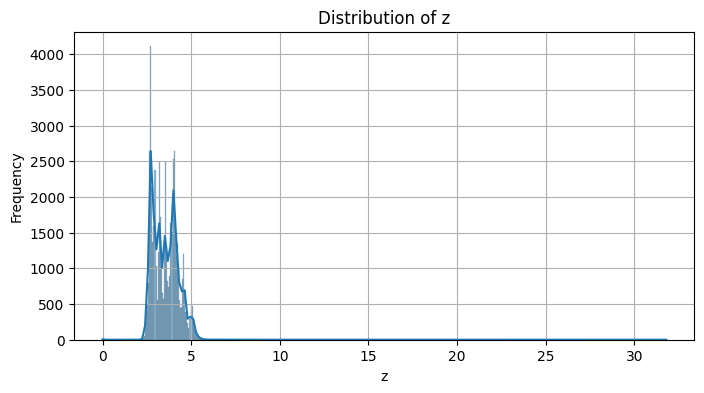

In [18]:
# Строим гистограмму распределения z
plot_hist_numeric(df, 'z')

Распределение данных напоминает распределение в y, но значения распределены в промежутке от 3 до 5 с выбросом в 3. 

### 3.2 Категориальные переменные

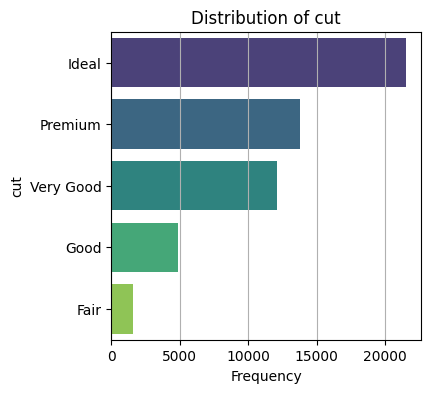

In [19]:
# Строим гистограмму распределения cut
plot_hist_categorical(df, 'cut')

Наблюдаем дисбаланс классов. Сильно недостает значений в классах Fair и Good

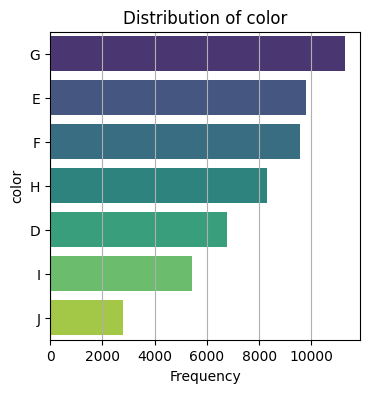

In [20]:
# Строим гистограмму распределения color
plot_hist_categorical(df, 'color')

В основном значения распределены равномерно, но в классах J, I, D заметно меньше значений. 

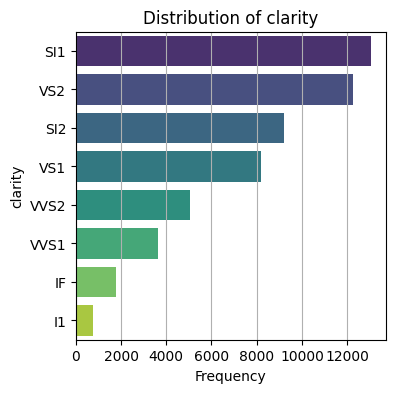

In [21]:
# Строим гистограмму распределения clarity
plot_hist_categorical(df, 'clarity')

Наблюдаем дисбаланс классов очень мало значений в классах I1, IF. Сильно мало значений в WS1 и WS2. 

## 4. Изучение взаимосвязей между признаками

### 4.1 Общая матрица корреляций

In [22]:
# удаляем столбец Unnamed: 0, поскольку он не несет пользы в дальнейшем исследовании
df = df.drop(columns=['Unnamed: 0'])

interval columns not set, guessing: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


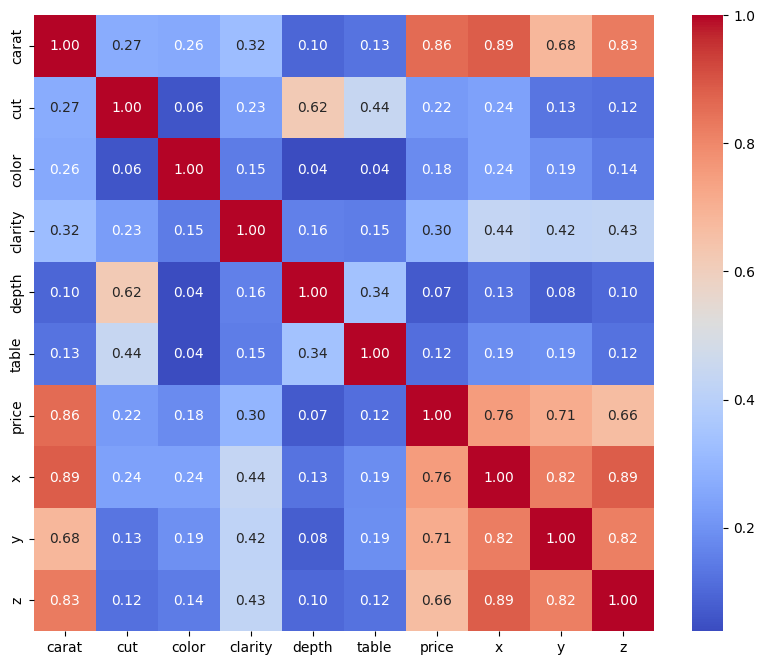

In [23]:
# поскольку в нашем датасете присутствуют категориальные признаки, используем корреляцию phik, которая способна с ними работать
plot_phik(df)

зависимости carat c x, y, z не будем рассматривать, так как связь очевидна (чем больше размер тем больше вес)
Рассмотрим следующие пары:

depth - table

price - carat


### 4.2 Подробное изучение корреляций между выбранными парами

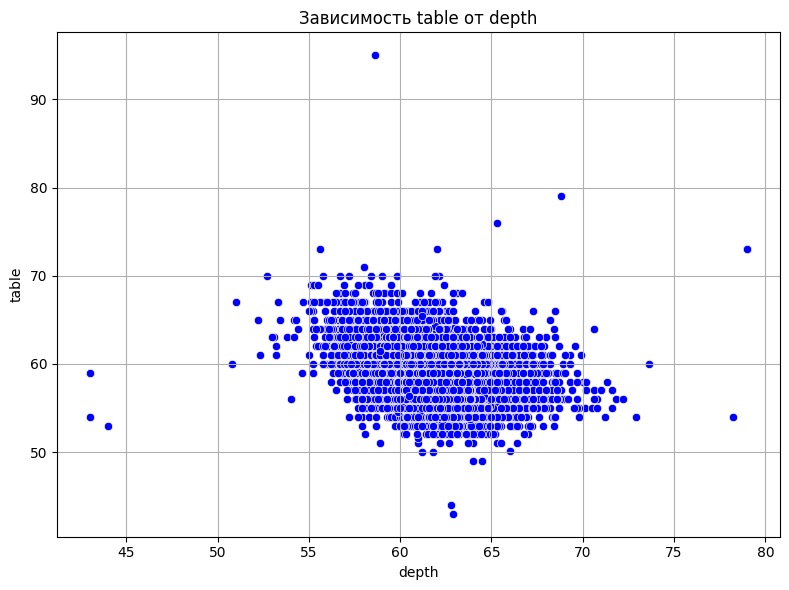

In [24]:
plot_numeric_relationship(df,'depth','table')

Видим что значения сгруппировались в достаточно плотную группу. 

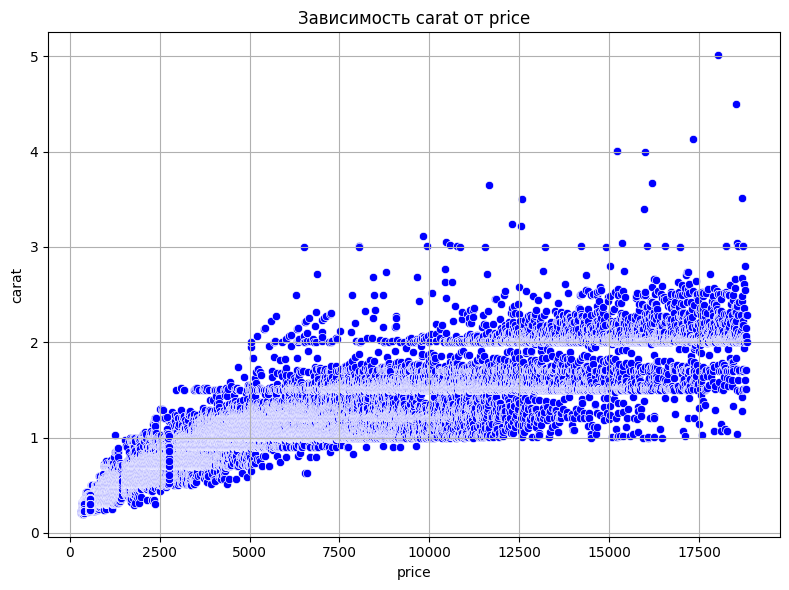

In [25]:
plot_numeric_relationship(df,'price','carat')

Можем наблюдать явную линейную зависимость. 

## 5. Препроцессинг данных

### 5.1 Общие преобразования

In [26]:
df_preprocessed = df.copy()

### 5.2 Разбиение датасета

In [27]:
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, 'price')

In [28]:
# Разбиваем данные на train и test с соотношением 80 на 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
)

In [29]:
X_train

,carat,cut,color,clarity,depth,table,x,y,z
26546,2.01,Good,F,SI2,58.1,64.0,8.23,8.19,4.77
9159,1.01,Very Good,E,SI2,60.0,60.0,6.57,6.49,3.92
14131,1.10,Premium,H,VS2,62.5,58.0,6.59,6.54,4.10
15757,1.50,Good,E,SI2,61.5,65.0,7.21,7.17,4.42
24632,1.52,Very Good,G,VS1,62.1,57.0,7.27,7.32,4.53
...,...,...,...,...,...,...,...,...,...
11284,1.05,Very Good,I,VS2,62.4,59.0,6.48,6.51,4.05
44732,0.47,Ideal,D,VS1,61.0,55.0,5.03,5.01,3.06
38158,0.33,Very Good,F,IF,60.3,58.0,4.49,4.46,2.70
860,0.90,Premium,J,SI1,62.8,59.0,6.13,6.03,3.82


In [30]:
X_train_preprocessed = X_train.copy()

In [31]:
categorical_cols = ['cut', 'color', 'clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

### 5.3 Кодирование категориальных переменных

In [32]:
# Будем использовать порядковое кодирование. Для этого выпишем все категории для каждого столбца в порядке увеличения номера
category_orders = [
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],   # cut                     
    ['J', 'I', 'H', 'G','F','E','D'],
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
]

encoder = OrdinalEncoder(categories=category_orders)
X_train_preprocessed[categorical_cols] = encoder.fit_transform(X_train_preprocessed[categorical_cols])

In [33]:
# посмотрим на результат работы кодировщика
X_train_preprocessed

,carat,cut,color,clarity,depth,table,x,y,z
26546,2.01,1.0,4.0,1.0,58.1,64.0,8.23,8.19,4.77
9159,1.01,2.0,5.0,1.0,60.0,60.0,6.57,6.49,3.92
14131,1.10,3.0,2.0,3.0,62.5,58.0,6.59,6.54,4.10
15757,1.50,1.0,5.0,1.0,61.5,65.0,7.21,7.17,4.42
24632,1.52,2.0,3.0,4.0,62.1,57.0,7.27,7.32,4.53
...,...,...,...,...,...,...,...,...,...
11284,1.05,2.0,1.0,3.0,62.4,59.0,6.48,6.51,4.05
44732,0.47,4.0,6.0,4.0,61.0,55.0,5.03,5.01,3.06
38158,0.33,2.0,4.0,7.0,60.3,58.0,4.49,4.46,2.70
860,0.90,3.0,0.0,2.0,62.8,59.0,6.13,6.03,3.82


In [34]:
# Создаем предобработчик данных в виде последовательного Pipeline
preprocessor = Pipeline([
    ('transformations', ColumnTransformer(
        [('encoder', OrdinalEncoder(categories=category_orders), categorical_cols)],
        remainder='passthrough',  # числовые колонки передаются без изменений
        verbose_feature_names_out=False
    ))
])

# Устанавливаем вывод в формате pandas DataFrame (для sklearn версии 1.0 и выше)
preprocessor.set_output(transform="pandas")

Pipeline(steps=[('transformations',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(categories=[['Fair',
                                                                              'Good',
                                                                              'Very '
                                                                              'Good',
                                                                              'Premium',
                                                                              'Ideal'],
                                                                             ['J',
                                                                              'I',
                                                                              'H',
                                                                              'G',
                                                                              'F',
                                                                              'E',
                                                                              'D'],
                                                                             ['I1',
                                                                              'SI2',
                                                                              'SI1',
                                                                              'VS2',
                                                                              'VS1',
                                                                              'VVS2',
                                                                              'VVS1',
                                                                              'IF']]),
                                                  ['cut', 'color', 'clarity'])],
                                   verbose_feature_names_out=False))])

In [35]:
# обучаем и применяем наш пайплайн к тестовой выборке
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, index=X_train.index)

In [36]:
# смотрим на результат работы пайплайна
X_train_preprocessed

,cut,color,clarity,carat,depth,table,x,y,z
26546,1.0,4.0,1.0,2.01,58.1,64.0,8.23,8.19,4.77
9159,2.0,5.0,1.0,1.01,60.0,60.0,6.57,6.49,3.92
14131,3.0,2.0,3.0,1.10,62.5,58.0,6.59,6.54,4.10
15757,1.0,5.0,1.0,1.50,61.5,65.0,7.21,7.17,4.42
24632,2.0,3.0,4.0,1.52,62.1,57.0,7.27,7.32,4.53
...,...,...,...,...,...,...,...,...,...
11284,2.0,1.0,3.0,1.05,62.4,59.0,6.48,6.51,4.05
44732,4.0,6.0,4.0,0.47,61.0,55.0,5.03,5.01,3.06
38158,2.0,4.0,7.0,0.33,60.3,58.0,4.49,4.46,2.70
860,3.0,0.0,2.0,0.90,62.8,59.0,6.13,6.03,3.82


## 6. Построение базовой модели (baseline)

### 6.1 Dummy regressor

In [37]:
# применяем уже обученный пайплайн к тестовой выборке.
X_test_preprocessed = preprocessor.transform(X_test)

In [38]:
feature_names = X_test_preprocessed.columns.to_list()

In [39]:
# Задаем и обучаем модель
dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train_preprocessed, y_train)

# Получаем предсказания
y_pred = dummy_regressor.predict(X_test_preprocessed) # предсказываем значение 

# Считаем метрики для модели и выводим графики
dummy_Regressor_metrics = evaluate_Regressor(
    y_test=y_test,
    y_pred=y_pred,
    model_name="DummyRegressor"
)


                 DUMMYREGRESSOR EVALUATION                  

MAIN METRICS:
Metric     Value
   MAE 3020.5058
  MAPE    1.9017
  RMSE 3987.2222
    R2   -0.0001



### 6.2 Линейная регрессия

In [40]:
lin_reg = SGDRegressor(random_state=SEED, max_iter=1000)
lin_reg.fit(X_train_preprocessed, y_train)

y_pred = lin_reg.predict(X_test_preprocessed)

lin_reg_metrics = evaluate_Regressor(
    y_test=y_test,
    y_pred=y_pred,
    model_name="Linear Regression"
)


                LINEAR REGRESSION EVALUATION                

MAIN METRICS:
Metric           Value
   MAE   76273469.8506
  MAPE      42869.5519
  RMSE   89695907.4203
    R2 -506098393.1104



### 6.3 Дерево решений

In [41]:
decision_tree = DecisionTreeRegressor(random_state=SEED, max_depth=8)
decision_tree.fit(X_train_preprocessed, y_train)

y_pred = decision_tree.predict(X_test_preprocessed)

decision_tree_metrics =  evaluate_Regressor(
    y_test=y_test,
    y_pred=y_pred,
    model_name="DecisionTreeRegressor"
)


              DECISIONTREEREGRESSOR EVALUATION              

MAIN METRICS:
Metric    Value
   MAE 388.0887
  MAPE   0.1105
  RMSE 699.2587
    R2   0.9692



c:\Users\Mikhail\VSC\проекты\Менторство\Задания\Classic ML\Регрессия\plots.py:314: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


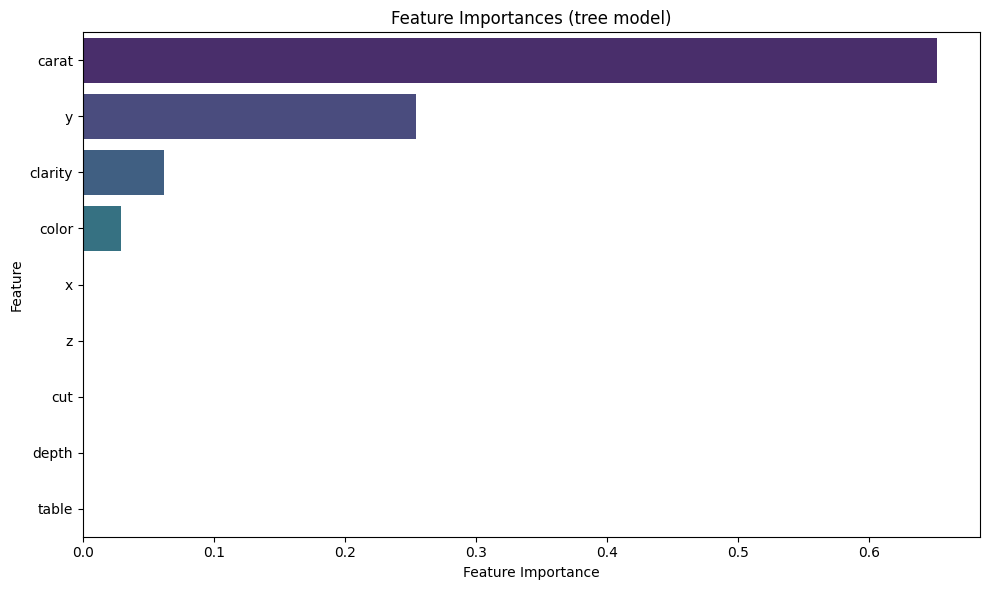

,Feature,Importance
3,carat,0.652005
7,y,0.254249
2,clarity,0.061975
1,color,0.029014
6,x,0.001131
8,z,0.001126
0,cut,0.000397
4,depth,0.000058
5,table,0.000046


In [42]:
plot_feature_importance(decision_tree, feature_names)

### 6.4 Случайный лес

In [43]:

random_forest = RandomForestRegressor(random_state=SEED)
random_forest.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = random_forest.predict(X_test_preprocessed)

# Evaluate
random_forest_metrics = evaluate_Regressor(
    y_test=y_test,
    y_pred=y_pred,
    model_name="RandomForestRegressor"
)


              RANDOMFORESTREGRESSOR EVALUATION              

MAIN METRICS:
Metric    Value
   MAE 266.5924
  MAPE   0.0635
  RMSE 540.9979
    R2   0.9816



c:\Users\Mikhail\VSC\проекты\Менторство\Задания\Classic ML\Регрессия\plots.py:314: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


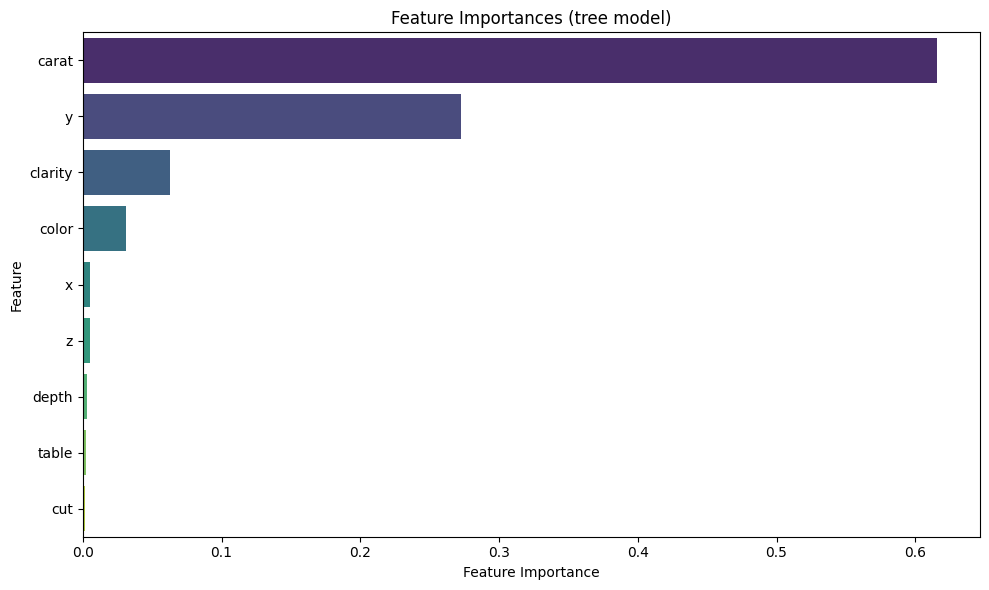

,Feature,Importance
3,carat,0.615866
7,y,0.272544
2,clarity,0.062980
1,color,0.031078
6,x,0.005177
8,z,0.005086
4,depth,0.003159
5,table,0.002282
0,cut,0.001827


In [44]:
plot_feature_importance(random_forest, feature_names)

### 6.5 Градиентный бустинг

In [45]:
# Train your model
lgbm = LGBMRegressor(random_state=SEED)
lgbm.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = lgbm.predict(X_test_preprocessed)

# Evaluate
lgbm_metrics = evaluate_Regressor(
    y_test=y_test,
    y_pred=y_pred,

    model_name="LGBMRegressor"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 43152, number of used features: 9
[LightGBM] [Info] Start training from score 3939.490707

                  LGBMREGRESSOR EVALUATION                  

MAIN METRICS:
Metric    Value
   MAE 276.4565
  MAPE   0.0806
  RMSE 530.8922
    R2   0.9823



c:\Users\Mikhail\VSC\проекты\Менторство\Задания\Classic ML\Регрессия\plots.py:314: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


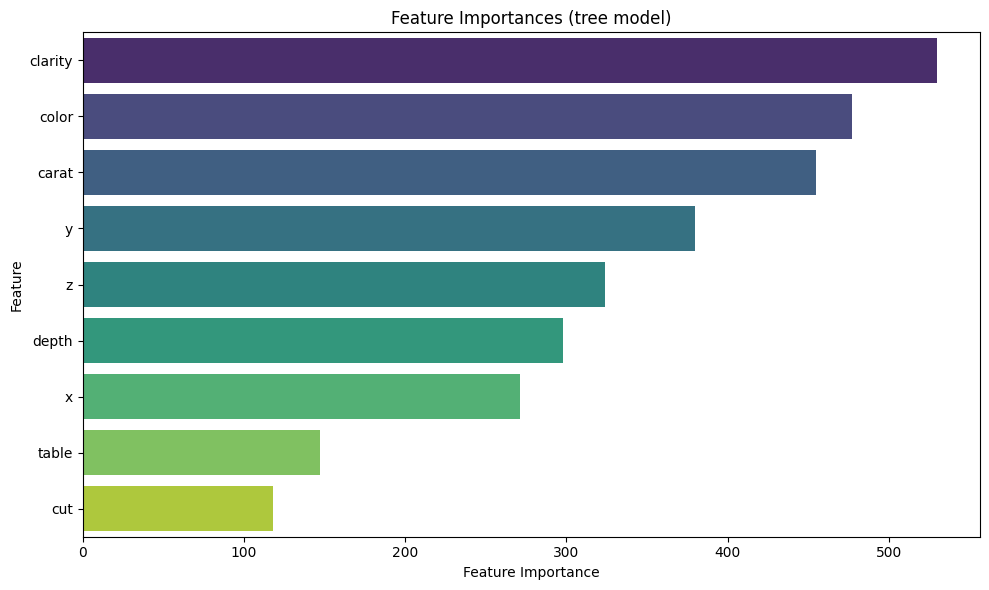

,Feature,Importance
2,clarity,530
1,color,477
3,carat,455
7,y,380
8,z,324
4,depth,298
6,x,271
5,table,147
0,cut,118


In [46]:
plot_feature_importance(lgbm, feature_names)

### 6.6 Финальное сравнение метрик

In [47]:
final_metrics = {
    'dummy_Regressor': dummy_Regressor_metrics,
    'lin_reg': lin_reg_metrics,
    'decision_tree': decision_tree_metrics,
    'random_forest': random_forest_metrics,
    'lgbm': lgbm_metrics
}

result = pd.DataFrame(final_metrics.values(), index=final_metrics.keys())

In [48]:
result

,MAE,MAPE,RMSE,R2
dummy_Regressor,3.020506e+03,1.901682,3.987222e+03,-7.040603e-05
lin_reg,7.627347e+07,42869.551851,8.969591e+07,-5.060984e+08
decision_tree,3.880887e+02,0.110511,6.992587e+02,9.692415e-01
random_forest,2.665924e+02,0.063523,5.409979e+02,9.815888e-01
lgbm,2.764565e+02,0.080581,5.308922e+02,9.822703e-01


<Axes: >

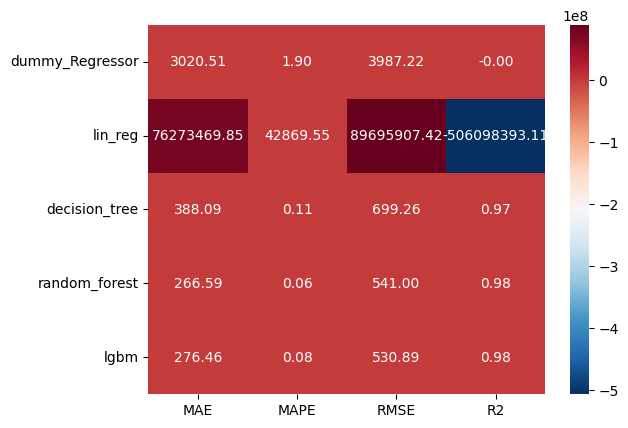

In [49]:
sns.heatmap(result, cmap='RdBu_r', annot=True, fmt=".2f")